## As of 5/26/2022, only R4 has been updated to include weighted area-averages (by latitude) for all 3 epochs.

In [ ]:
import glob as glob
import xarray as xr
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import proplot as pplt
from sklearn.linear_model import LinearRegression
from matplotlib.ticker import(MultipleLocator, FormatStrFormatter, AutoMinorLocator)
import dask
dask.config.set({"array.slicing.split_large_chunks": False})

##########################################################################################################################################
#########################################################################################################################################
#### Large SE US Domain ####
lat_r4 = slice(25,43)
lon_r4 = slice(256,291)
loc_r4 = 'Large SE US Domain'

#########################################################
variable1 = 'mcape'
var1 = 'CAPE'
name1 = 'cape.'  
cesm_title1 = 'CAPE'
units1 = 'J/kg'

variable2 = 'S06'
var2 = 'S06'
name2 = 's06'   
cesm_title2 = 'S06'
units2 = 'm/s'

variable3 = 'capes06'
var3 = 'CAPES06'
name3 = 'capes06'   
cesm_title3 = 'CAPES06'
units3 = 'm$^{3}$/s$^{3}$'

variable4 = 'mcin'
var4 = 'CIN'
name4 = 'cin'   
cesm_title4 = 'CIN'
units4 = 'J/kg'

#########################################################
e1_start = '2021'
e1_end = '2050'
e2_start = '2041'
e2_end = '2071'
e3_start = '2071'
e3_end = '2100'

startpoint = '2021'
endpoint = '2050'
point = '(2021-2050)'

### Masking Data ###
mask = xr.open_dataset('p_cal_cesm2_mask.nc')


### CAPE

In [2]:
h_files = sorted(glob.glob('cape.*.1870-2014.nc'))   #### This is for anomalies 
f_files = x'cape.*.2015-2100.nc'))   #### This is for anomalies 

hist = xr.open_mfdataset(h_files, concat_dim = 'realization', combine = 'nested').where(mask.LSMASK == 1.0)
fut = xr.open_mfdataset(f_files, concat_dim = 'realization', combine = 'nested').where(mask.LSMASK == 1.0)
total = xr.concat([hist,fut], dim = 'time')[variable1]
mamj = total.groupby('time.year').mean('time').sel(lat = lat_r4, lon = lon_r4)

# ##### Weight the area average by latitude: 
weights = np.cos(np.deg2rad(mamj.lat))
weights.name = "weights"
mamj_weighted = mamj.weighted(weights)
r4 = mamj_weighted.mean(("lon", "lat"))

####################### Loop over all ensembles: ###########################################################
ry = list()
rx = list()
a_r = list()
b_r = list()
reg = list()
trend_r4 = list()
slope_r4= list()

r4_LT = r4.sel(year=slice(startpoint, endpoint))

for i in range(len(r4)):
    ry.append(r4_LT[i,:].values)
    rx.append(r4_LT[i,:].year.values)
    a_r.append(rx[i].reshape(-1,1))
    b_r.append(ry[i].reshape(-1,1))
    reg.append(LinearRegression().fit(a_r[i], b_r[i]))
    trend_r4.append(reg[i].predict(a_r[i]))
    slope_r4.append(reg[i].coef_[0])

############################################### Find the max and min trend values: #######################################################
max_index_r4 = slope_r4.index(np.max(slope_r4))    #### Ensemble xx has the largest slope for r4 CAPE
min_index_r4 = slope_r4.index(np.min(slope_r4))     ##### Ensemble x has the smallest slope for r4 CAPE

r4_maxTrend = trend_r4[max_index_r4]
r4_minTrend = trend_r4[min_index_r4]
r4_maxEns = r4[max_index_r4]
r4_minEns = r4[min_index_r4]

print('r4 max index for v1: ' + str(max_index_r4) + ' r4 max: ' + str(round(np.max(slope_r4),3)))
print('r4 min index for v1: ' + str(min_index_r4) + ' r4 min: ' + str(round(np.min(slope_r4),3)))


LT_values_r4_v1 = pd.DataFrame(slope_r4)
v1_dec = LT_values_r4_v1 * 10


r4 max index for v1: 23 r4 max: 7.045
r4 min index for v1: 13 r4 min: -0.304


## S06

In [3]:
h_files = sorted(glob.glob('s06.*.1870-2014.nc'))   #### This is for anomalies 
f_files = sorted(glob.glob('s06.*.2015-2100.nc'))   #### This is for anomalies 

hist = xr.open_mfdataset(h_files, concat_dim = 'realization', combine = 'nested').where(mask.LSMASK == 1.0)
fut = xr.open_mfdataset(f_files, concat_dim = 'realization', combine = 'nested').where(mask.LSMASK == 1.0)
total = xr.concat([hist,fut], dim = 'time')[variable2]
mamj = total.groupby('time.year').mean('time').sel(lat = lat_r4, lon = lon_r4)

# ##### Weight the area average by latitude: 
weights = np.cos(np.deg2rad(mamj.lat))
weights.name = "weights"
mamj_weighted = mamj.weighted(weights)
r4 = mamj_weighted.mean(("lon", "lat"))

####################### Loop over all ensembles: ###########################################################
ry = list()
rx = list()
a_r = list()
b_r = list()
reg = list()
trend_r4 = list()
slope_r4= list()

r4_LT = r4.sel(year=slice(startpoint, endpoint))

for i in range(len(r4)):
    ry.append(r4_LT[i,:].values)
    rx.append(r4_LT[i,:].year.values)
    a_r.append(rx[i].reshape(-1,1))
    b_r.append(ry[i].reshape(-1,1))
    reg.append(LinearRegression().fit(a_r[i], b_r[i]))
    trend_r4.append(reg[i].predict(a_r[i]))
    slope_r4.append(reg[i].coef_[0])

############################################### Find the max and min trend values: #######################################################
max_index_r4 = slope_r4.index(np.max(slope_r4))    #### Ensemble xx has the largest slope for r4 S06 
min_index_r4 = slope_r4.index(np.min(slope_r4))     ##### Ensemble xx has the smallest slope for r4 S06

r4_maxTrend = trend_r4[max_index_r4]
r4_minTrend = trend_r4[min_index_r4]
r4_maxEns = r4[max_index_r4]
r4_minEns = r4[min_index_r4]

print('r4 max index for v2: ' + str(max_index_r4) + ' r4 max: ' + str(round(np.max(slope_r4),3)))
print('r4 min index for v2: ' + str(min_index_r4) + ' r4 min: ' + str(round(np.min(slope_r4),3)))


LT_values_r4_v2 = pd.DataFrame(slope_r4)
v2_dec = LT_values_r4_v2 * 10




r4 max index for v2: 17 r4 max: 0.017
r4 min index for v2: 34 r4 min: -0.089


## CAPES06

In [4]:
h_files = sorted(glob.glob('capes06.*.1870-2014.nc'))   #### This is for anomalies 
f_files = sorted(glob.glob('capes06.*.2015-2100.nc'))   #### This is for anomalies 

hist = xr.open_mfdataset(h_files, concat_dim = 'realization', combine = 'nested').where(mask.LSMASK == 1.0)
fut = xr.open_mfdataset(f_files, concat_dim = 'realization', combine = 'nested').where(mask.LSMASK == 1.0)
total = xr.concat([hist,fut], dim = 'time')[variable3]
mamj = total.groupby('time.year').mean('time').sel(lat = lat_r4, lon = lon_r4)

# ##### Weight the area average by latitude: 
weights = np.cos(np.deg2rad(mamj.lat))
weights.name = "weights"
mamj_weighted = mamj.weighted(weights)
r4 = mamj_weighted.mean(("lon", "lat"))

####################### Loop through all ensemble members: ###########################################################
ry = list()
rx = list()
a_r = list()
b_r = list()
reg = list()
trend_r4 = list()
slope_r4= list()

r4_LT = r4.sel(year=slice(startpoint, endpoint))

for i in range(len(r4)):
    ry.append(r4_LT[i,:].values)
    rx.append(r4_LT[i,:].year.values)
    a_r.append(rx[i].reshape(-1,1))
    b_r.append(ry[i].reshape(-1,1))
    reg.append(LinearRegression().fit(a_r[i], b_r[i]))
    trend_r4.append(reg[i].predict(a_r[i]))
    slope_r4.append(reg[i].coef_[0])

############################################### Find the max and min trend values: #######################################################
max_index_r4 = slope_r4.index(np.max(slope_r4))    #### Ensemble xx has the largest slope for r4 CAPES06 
min_index_r4 = slope_r4.index(np.min(slope_r4))     ##### Ensemble xx has the smallest slope for r4 CAPES06

r4_maxTrend = trend_r4[max_index_r4]
r4_minTrend = trend_r4[min_index_r4]
r4_maxEns = r4[max_index_r4]
r4_minEns = r4[min_index_r4]

print('r4 max index for v3: ' + str(max_index_r4) + ' r4 max: ' + str(round(np.max(slope_r4),3)))
print('r4 min index for v3: ' + str(min_index_r4) + ' r4 min: ' + str(round(np.min(slope_r4),3)))

LT_values_r4_v3 = pd.DataFrame(slope_r4)
v3_dec = LT_values_r4_v3 * 10




r4 max index for v3: 23 r4 max: 79.109
r4 min index for v3: 25 r4 min: -18.247


## CIN

In [5]:
h_files = sorted(glob.glob('cin.*.1870-2014.nc'))   #### This is for anomalies 
f_files = sorted(glob.glob('cin.*.2015-2100.nc'))   #### This is for anomalies 

hist = xr.open_mfdataset(h_files, concat_dim = 'realization', combine = 'nested').where(mask.LSMASK == 1.0)
fut = xr.open_mfdataset(f_files, concat_dim = 'realization', combine = 'nested').where(mask.LSMASK == 1.0)
total = xr.concat([hist,fut], dim = 'time')[variable4]
mamj = total.groupby('time.year').mean('time').sel(lat = lat_r4, lon = lon_r4)*(-1)

# ##### Weight the area average by latitude: 
weights = np.cos(np.deg2rad(mamj.lat))
weights.name = "weights"
mamj_weighted = mamj.weighted(weights)
r4 = mamj_weighted.mean(("lon", "lat"))

####################### Loop through all ensemble members: ###########################################################
ry = list()
rx = list()
a_r = list()
b_r = list()
reg = list()
trend_r4 = list()
slope_r4= list()

r4_LT = r4.sel(year=slice(startpoint, endpoint))

for i in range(len(r4)):
    ry.append(r4_LT[i,:].values)
    rx.append(r4_LT[i,:].year.values)
    a_r.append(rx[i].reshape(-1,1))
    b_r.append(ry[i].reshape(-1,1))
    reg.append(LinearRegression().fit(a_r[i], b_r[i]))
    trend_r4.append(reg[i].predict(a_r[i]))
    slope_r4.append(reg[i].coef_[0])

############################################### Find the max and min trend values: #######################################################
max_index_r4 = slope_r4.index(np.max(slope_r4))    #### Ensemble XX has the largest slope for r4 CIN 
min_index_r4 = slope_r4.index(np.min(slope_r4))     ##### Ensemble XX has the smallest slope for r4 CIN

r4_maxTrend = trend_r4[max_index_r4]
r4_minTrend = trend_r4[min_index_r4]
r4_maxEns = r4[max_index_r4]
r4_minEns = r4[min_index_r4]

print('r4 max index for v4: ' + str(max_index_r4) + ' r4 max: ' + str(round(np.max(slope_r4),3)))
print('r4 min index for v4: ' + str(min_index_r4) + ' r4 min: ' + str(round(np.min(slope_r4),3)))


LT_values_r4_v4 = pd.DataFrame(slope_r4)
v4_dec = LT_values_r4_v4 * 10


r4 max index for v4: 20 r4 max: 0.273
r4 min index for v4: 28 r4 min: -0.446


### Plotting

/Users/mfranke/opt/miniconda3/lib/python3.7/site-packages/ipykernel_launcher.py:15: ProplotWarning: Calling arbitrary axes methods from SubplotGrid was deprecated in v0.8 and will be removed in a future release. Please index the grid or loop over the grid instead.
  from ipykernel import kernelapp as app
/Users/mfranke/opt/miniconda3/lib/python3.7/site-packages/ipykernel_launcher.py:20: ProplotWarning: Calling arbitrary axes methods from SubplotGrid was deprecated in v0.8 and will be removed in a future release. Please index the grid or loop over the grid instead.
/Users/mfranke/opt/miniconda3/lib/python3.7/site-packages/ipykernel_launcher.py:21: ProplotWarning: Calling arbitrary axes methods from SubplotGrid was deprecated in v0.8 and will be removed in a future release. Please index the grid or loop over the grid instead.
/Users/mfranke/opt/miniconda3/lib/python3.7/site-packages/ipykernel_launcher.py:22: ProplotWarning: Calling arbitrary axes methods from SubplotGrid was deprecated i

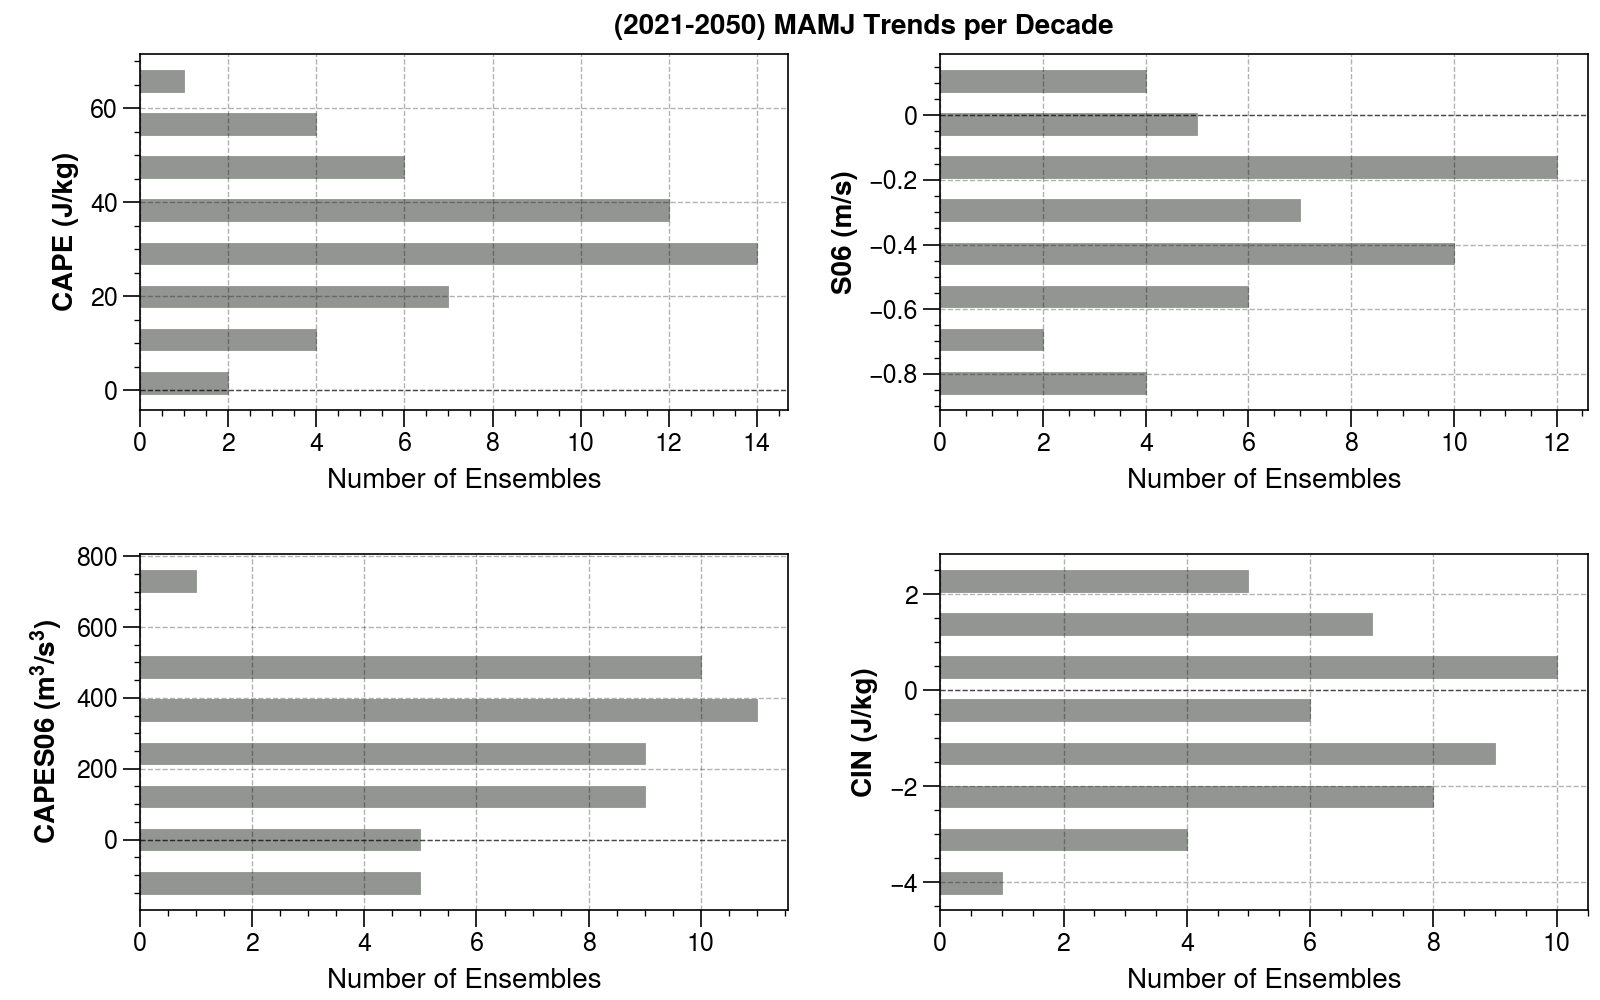

In [12]:
plt.rcParams['figure.facecolor'] = 'white'
binsNum = 8
fc = 'grey'
fc_era = 'red'
ft = 10
fig, axs = pplt.subplots(ncols=2, nrows=2, figsize =(8, 5), sharey = False, sharex = False)
ax1,ax2,ax3,ax4 = axs
fig.suptitle(point + ' MAMJ Trends per Decade', fontsize = 10)
v1_dec.plot.hist(ax=ax1, bins = binsNum, histtype = 'barstacked', legend = None, Fill = True, facecolor = fc, orientation = 'horizontal', rwidth = .5)
v2_dec.plot.hist(ax=ax2, bins = binsNum, histtype = 'barstacked', legend = None, Fill = True, facecolor = fc, orientation = 'horizontal', rwidth = .5)
v3_dec.plot.hist(ax=ax3, bins = binsNum, histtype = 'barstacked', legend = None, Fill = True, facecolor = fc, orientation = 'horizontal', rwidth = .5)
v4_dec.plot.hist(ax=ax4, bins = binsNum, histtype = 'barstacked', legend = None, Fill = True, facecolor = fc, orientation = 'horizontal', rwidth = .5)


axs.set_xlabel('Number of Ensembles', fontsize = ft)
ax1.set_ylabel(var1 + ' ('+ units1 +')', fontsize = ft, weight = 'bold')
ax2.set_ylabel(var2 + ' ('+ units2 +')', fontsize = ft, weight = 'bold')
ax3.set_ylabel(var3 + ' ('+ units3 +')', fontsize = ft, weight = 'bold')
ax4.set_ylabel(var4 + ' ('+ units4 +')', fontsize = ft, weight = 'bold')
axs.tick_params(which='major', length=6, color='k', labelsize=9)
axs.tick_params(which='minor', length=2, color='k')
axs.axhline(color = 'black', alpha = .6, linewidth=.5, linestyle="--")
axs.grid(axis="x", color="black", alpha=.3, linewidth=.5, linestyle="--")
axs.grid(axis="y", color="black", alpha=.3, linewidth=.5, linestyle="--")
fig.tight_layout(pad=6.0)

# plt.savefig('Figures/Histograms/histogram_allParams_decadalTrends_weighted_JGR.jpg', dpi = 500)

